In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from tools import load_data

## Impact between: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$ and $\mathbf{X} \rightarrow F|_{\mathrm{targets}}$

How exactly is it possible to determine the force $F$ at different positions $A$?

In [2]:
X, T, F, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

In [4]:
target_A_names = [20, 40, 60, 80]
tol = 1

targets_A = {}
for tns in target_A_names:
    ps = indices_with_tolerance(A, tns, tol)  # Adjustment place
    np.random.shuffle(ps)
    targets_A[tns] = ps
y_label_A = [f"{tns}$\pm${tol}°" for tns in target_A_names]  # Adjustment place

Found 1,043 for position 20 and a tolerance of 1.
Found 1,049 for position 40 and a tolerance of 1.
Found 1,039 for position 60 and a tolerance of 1.
Found 1,067 for position 80 and a tolerance of 1.


In [5]:
targets_A

{20: array([44919, 65172, 24959, ..., 16277, 10327,  9002], shape=(1043,)),
 40: array([29579, 65113, 34258, ..., 61877, 59211, 39044], shape=(1049,)),
 60: array([ 5327, 36009, 34549, ...,  1760, 45487, 11716], shape=(1039,)),
 80: array([56347, 47227, 14705, ..., 51681, 39299,  5889], shape=(1067,))}

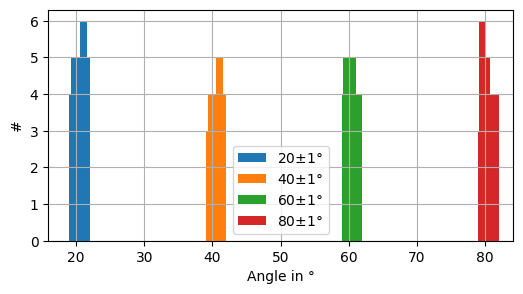

In [6]:
plt.figure(figsize=(6, 3))
for tars_kys, tars_vls in targets_A.items():
    plt.hist(
        A[tars_vls], bins=len(A[tars_vls]), label=tars_kys, align="mid", width=1
    )  # Adjustment place
plt.grid()
plt.legend(y_label_A)
plt.ylabel("#")
plt.xlabel("Angle in °")  # Adjustment place
plt.show()

In [7]:
target_F_names = [50, 75, 100, 125, 150, 175, 200]

tol = 2
targets_F = {}
for tns in target_F_names:
    ps = indices_with_tolerance(F, tns, tol)  # Adjustment place
    np.random.shuffle(ps)
    targets_F[tns] = ps
y_label_F = [f"{tns}$\pm${tol}N" for tns in target_F_names]  # Adjustment place

Found 1,208 for position 50 and a tolerance of 2.
Found 1,562 for position 75 and a tolerance of 2.
Found 1,464 for position 100 and a tolerance of 2.
Found 1,545 for position 125 and a tolerance of 2.
Found 1,280 for position 150 and a tolerance of 2.
Found 875 for position 175 and a tolerance of 2.
Found 901 for position 200 and a tolerance of 2.


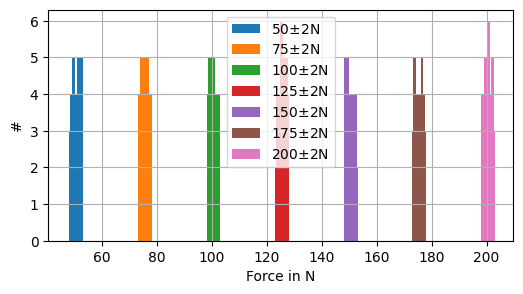

In [8]:
plt.figure(figsize=(6, 3))
for tars_kys, tars_vls in targets_F.items():
    plt.hist(
        F[tars_vls], bins=len(F[tars_vls]), label=tars_kys, align="mid", width=1
    )  # Adjustment place
plt.grid()
plt.legend(y_label_F)
plt.ylabel("#")
plt.xlabel("Force in N")  # Adjustment place
plt.show()

In [9]:
targets_F.keys()

dict_keys([50, 75, 100, 125, 150, 175, 200])

In [10]:
targets_A.keys()

dict_keys([20, 40, 60, 80])

**Evaluate force $F$ at discrete angles $A$**

In [13]:
params_path = "params/TrainValid_F_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)

best_model = RandomForestClassifier(**best_params_)  # Adjustment place
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Loaded params


In [14]:
SCORES = []
R2 = []
for tars_kys, tars_vls in targets_A.items():
    print(f"Discrete target angle: {tars_kys}°")
    XA = X[tars_vls]
    FA = F[tars_vls]
    PA = P[tars_vls]
    # test the classification ability for Force at the corresponding angle
    targets = np.concatenate(
        [indices_with_tolerance(FA, tF, tol) for tF in targets_F.keys()]
    )
    np.random.shuffle(targets)

    y = FA[targets]  # F -> Force # Adjustment place
    EIT = XA[targets]
    Pwise = PA[targets]

    y_cont = y.reshape(-1, 1)
    binning = KBinsDiscretizer(
        n_bins=3,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf",
    )
    y = binning.fit_transform(y_cont).ravel()

    # compute force classification for specific angle

    cmy_pred = []
    cmy_true = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
        X_train, X_valid = EIT[train_idx], EIT[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_valid)

        cmy_pred.append(y_pred)
        cmy_true.append(y_valid)

        acc = balanced_accuracy_score(y_valid, y_pred)
        print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

    cmy_pred = np.concatenate(cmy_pred)
    cmy_true = np.concatenate(cmy_true)

    print(f"\naccuracy_score: {accuracy_score(cmy_true, cmy_pred):.4f}")
    print(f"balanced_accuracy_score: {balanced_accuracy_score(cmy_true, cmy_pred):.4f}")
    print(f"r2_score: {r2_score(cmy_true, cmy_pred):.4f}")
    print("----------------------------")
    SCORES.append(balanced_accuracy_score(cmy_true, cmy_pred))
    R2.append(r2_score(cmy_true, cmy_pred))

print(f"\nScores mean: {np.mean(SCORES)}")
print(f"R² mean: {np.mean(R2)}")

Discrete target angle: 20°
Found 15 for position 50 and a tolerance of 2.
Found 25 for position 75 and a tolerance of 2.
Found 22 for position 100 and a tolerance of 2.
Found 41 for position 125 and a tolerance of 2.
Found 35 for position 150 and a tolerance of 2.
Found 26 for position 175 and a tolerance of 2.
Found 8 for position 200 and a tolerance of 2.
Fold 1 Balanced Accuracy: 0.8283
Fold 2 Balanced Accuracy: 0.8005
Fold 3 Balanced Accuracy: 0.8005
Fold 4 Balanced Accuracy: 0.8232
Fold 5 Balanced Accuracy: 0.7929

accuracy_score: 0.8081
balanced_accuracy_score: 0.8083
r2_score: 0.6087
----------------------------
Discrete target angle: 40°
Found 2 for position 50 and a tolerance of 2.
Found 25 for position 75 and a tolerance of 2.
Found 17 for position 100 and a tolerance of 2.
Found 30 for position 125 and a tolerance of 2.
Found 34 for position 150 and a tolerance of 2.
Found 18 for position 175 and a tolerance of 2.
Found 17 for position 200 and a tolerance of 2.
Fold 1 Balanc

**Evaluate anlge $A$ at discrete forces $F$**

In [15]:
params_path = "params/TrainValid_A_RF.pkl"  # Adjustment place

if os.path.exists(params_path):
    print("Loaded params")
    best_params_ = joblib.load(params_path)

best_model = RandomForestClassifier(**best_params_)  # Adjustment place
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Loaded params


In [16]:
SCORES = []
R2 = []
for tars_kys, tars_vls in targets_F.items():
    print(f"Discrete target force: {tars_kys}N")
    XF = X[tars_vls]
    AF = A[tars_vls]
    PF = P[tars_vls]
    # test the classification ability for Force at the corresponding angle
    targets = np.concatenate(
        [indices_with_tolerance(AF, tA, tol) for tA in targets_A.keys()]
    )
    np.random.shuffle(targets)
    y = AF[targets]
    EIT = XF[targets]
    Pwise = PF[targets]

    y_cont = y.reshape(-1, 1)
    binning = KBinsDiscretizer(
        n_bins=3,
        encode="ordinal",
        strategy="quantile",
        quantile_method="averaged_inverted_cdf",
    )
    y = binning.fit_transform(y_cont).ravel()
    # compute force classification for specific angle

    cmy_pred = []
    cmy_true = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(EIT, y), 1):
        X_train, X_valid = EIT[train_idx], EIT[valid_idx]
        y_train, y_valid = y[train_idx], y[valid_idx]

        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_valid)

        cmy_pred.append(y_pred)
        cmy_true.append(y_valid)

        acc = balanced_accuracy_score(y_valid, y_pred)
        print(f"Fold {fold} Balanced Accuracy: {acc:.4f}")

    cmy_pred = np.concatenate(cmy_pred)
    cmy_true = np.concatenate(cmy_true)

    print(f"\naccuracy_score: {accuracy_score(cmy_true, cmy_pred):.4f}")
    print(f"balanced_accuracy_score: {balanced_accuracy_score(cmy_true, cmy_pred):.4f}")
    print(f"r2_score: {r2_score(cmy_true, cmy_pred):.4f}")
    print("----------------------------")
    SCORES.append(balanced_accuracy_score(cmy_true, cmy_pred))
    R2.append(r2_score(cmy_true, cmy_pred))

print(f"\nScores mean: {np.mean(SCORES)}")
print(f"R² mean: {np.mean(R2)}")

Discrete target force: 50N
Found 24 for position 20 and a tolerance of 2.
Found 10 for position 40 and a tolerance of 2.
Found 9 for position 60 and a tolerance of 2.
Found 10 for position 80 and a tolerance of 2.
Fold 1 Balanced Accuracy: 0.8056
Fold 2 Balanced Accuracy: 0.8056
Fold 3 Balanced Accuracy: 0.7222
Fold 4 Balanced Accuracy: 0.7222
Fold 5 Balanced Accuracy: 0.8056

accuracy_score: 0.7736
balanced_accuracy_score: 0.7723
r2_score: 0.4854
----------------------------
Discrete target force: 75N
Found 51 for position 20 and a tolerance of 2.
Found 45 for position 40 and a tolerance of 2.
Found 44 for position 60 and a tolerance of 2.
Found 63 for position 80 and a tolerance of 2.
Fold 1 Balanced Accuracy: 0.8553
Fold 2 Balanced Accuracy: 0.8773
Fold 3 Balanced Accuracy: 0.8993
Fold 4 Balanced Accuracy: 0.7692
Fold 5 Balanced Accuracy: 0.9762

accuracy_score: 0.8768
balanced_accuracy_score: 0.8767
r2_score: 0.7259
----------------------------
Discrete target force: 100N
Found 49 

- $R^2 = 1.0$ → perfekte Vorhersage
- $R^2 = 0.0$ → genauso gut wie immer den Mittelwert vorhersagen
- $R^2 < 0.0$ → schlechter als der Mittelwert

___